In [1]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (4000, 28)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [5]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df = df.drop_duplicates()

print("Rows and Columns after cleaning:", df.shape)

Rows and Columns after cleaning: (4000, 28)


In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


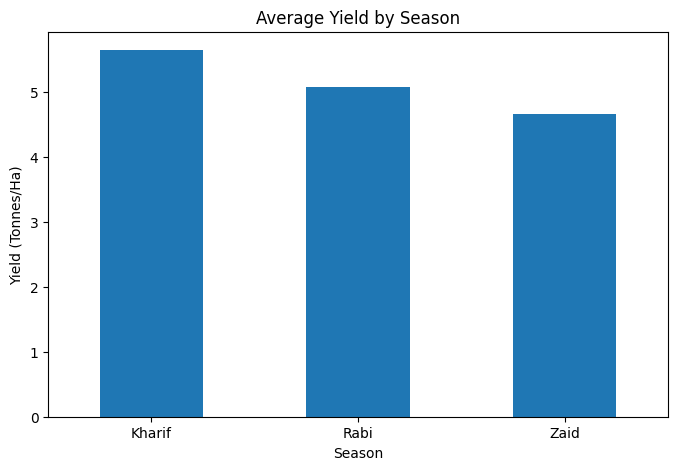

In [11]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(season_yield)

season_yield.plot(kind="bar", figsize=(8,5))
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


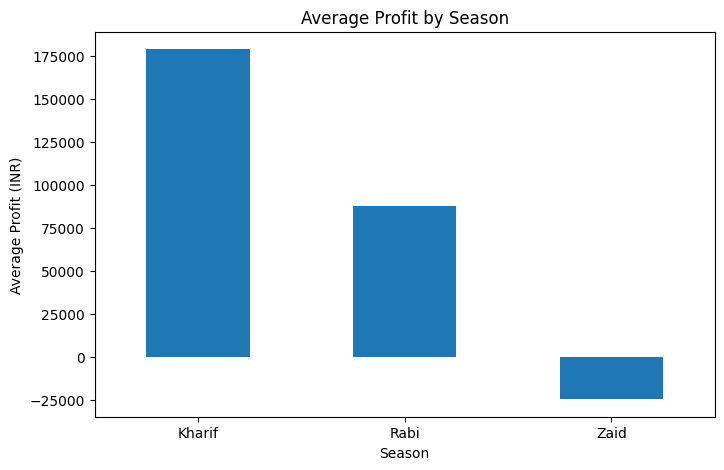

In [12]:
season_profit = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)

print(season_profit)

season_profit.plot(kind="bar", figsize=(8,5))
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.show()

Crop
Sugarcane    46.938746
Maize         2.717130
Rice          2.439413
Wheat         2.109216
Chilli        1.540344
Groundnut     1.317924
Cotton        1.225734
Pulses        0.918198
Name: Yield_Tonnes_Ha, dtype: float64


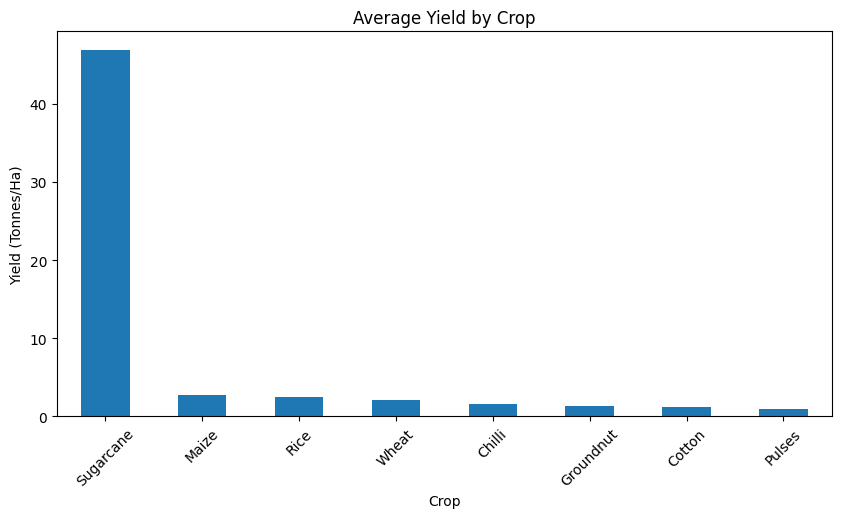

In [13]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(crop_yield)

crop_yield.plot(kind="bar", figsize=(10,5))
plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


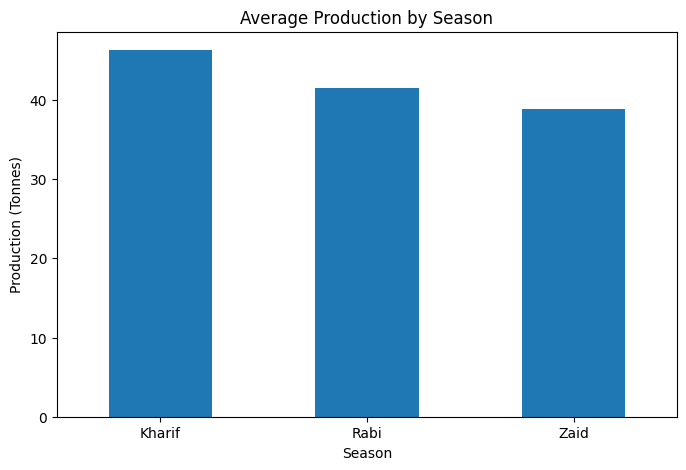

In [14]:
season_production = df.groupby("Season")["Production_Tonnes"].mean().sort_values(ascending=False)

print(season_production)

season_production.plot(kind="bar", figsize=(8,5))
plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")
plt.xticks(rotation=0)
plt.show()

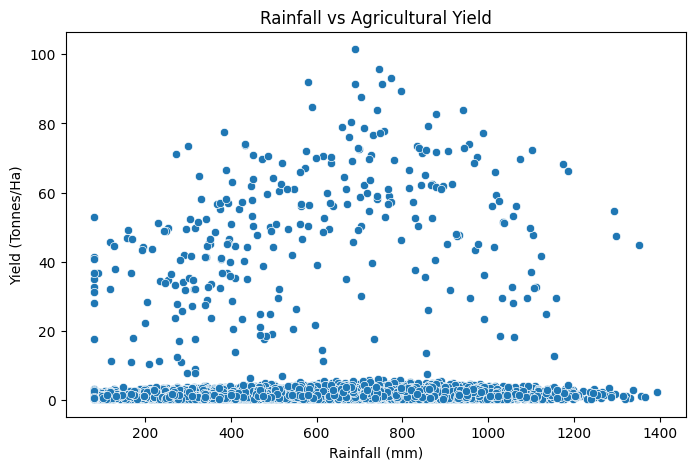

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha")
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

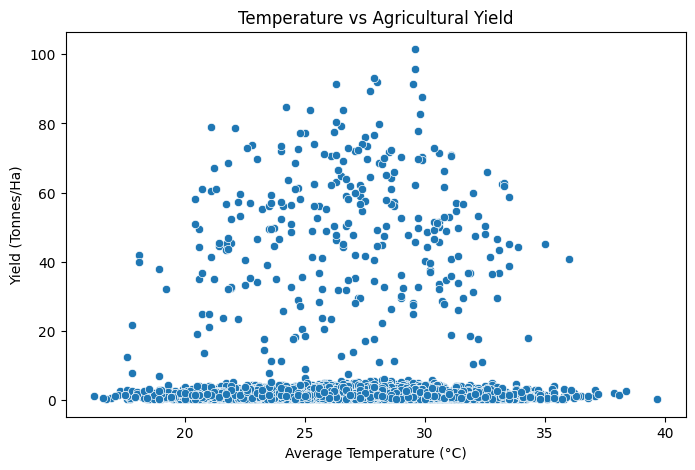

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Avg_Temperature_C", y="Yield_Tonnes_Ha")
plt.title("Temperature vs Agricultural Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

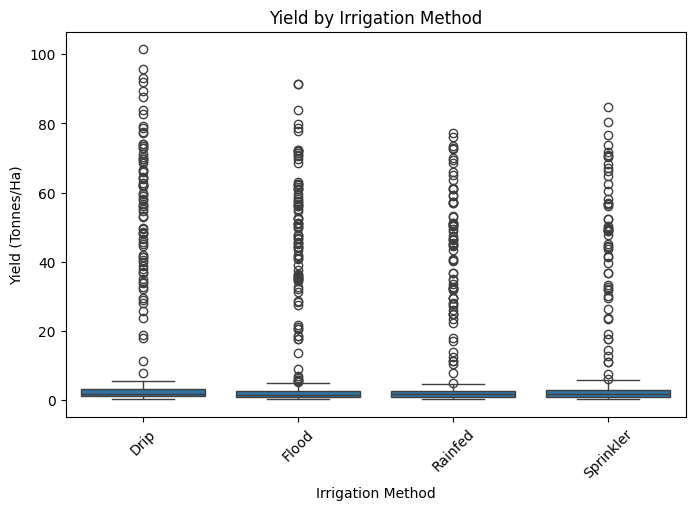

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha")
plt.title("Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

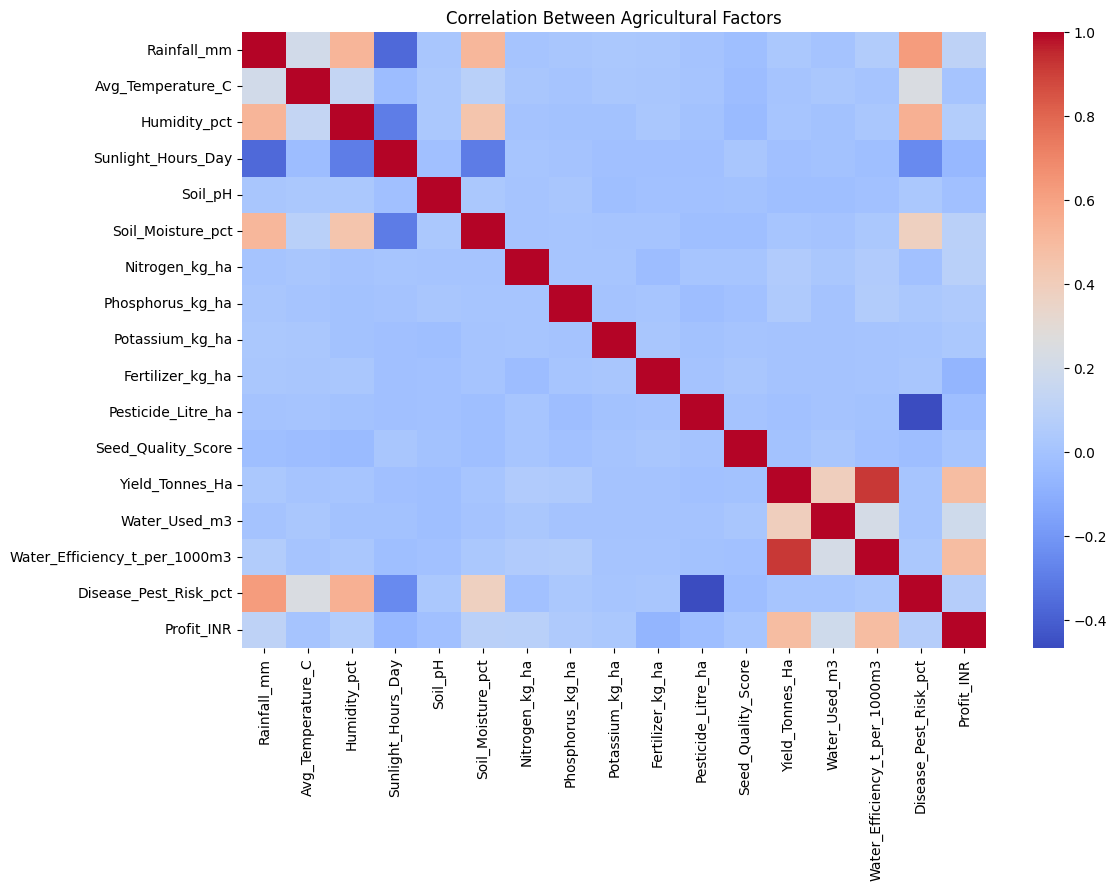

In [18]:
numeric_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct",
    "Profit_INR"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Between Agricultural Factors")
plt.show()

In [20]:
# FINAL ANALYSIS TABLES

print("===== 1. SEASON-WISE PERFORMANCE =====")
season_summary = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2)

print(season_summary)


print("\n===== 2. CROP-WISE PERFORMANCE =====")
crop_summary = df.groupby("Crop").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2).sort_values("Average_Yield", ascending=False)

print(crop_summary)


print("\n===== 3. IRRIGATION-WISE PERFORMANCE =====")
irrigation_summary = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().round(2).sort_values(ascending=False)

print(irrigation_summary)


print("\n===== 4. SEASON-WISE ENVIRONMENT =====")
environment_summary = df.groupby("Season").agg(
    Rainfall=("Rainfall_mm", "mean"),
    Temperature=("Avg_Temperature_C", "mean"),
    Humidity=("Humidity_pct", "mean")
).round(2)

print(environment_summary)


print("\n===== 5. HIGHEST PROFITABLE CROP =====")
print(crop_summary["Average_Profit"].sort_values(ascending=False).head())


print("\n===== 6. HIGHEST YIELDING CROP =====")
print(crop_summary["Average_Yield"].head())


print("\n===== 7. CORRELATION WITH YIELD =====")
yield_corr = df[numeric_cols].corr()["Yield_Tonnes_Ha"].sort_values(ascending=False)

print(yield_corr)


print("\n===== 8. CORRELATION WITH PROFIT =====")
profit_corr = df[numeric_cols].corr()["Profit_INR"].sort_values(ascending=False)

print(profit_corr)

===== 1. SEASON-WISE PERFORMANCE =====
        Average_Yield  Average_Production  Average_Profit
Season                                                   
Kharif           5.64               46.31       178914.65
Rabi             5.08               41.49        87689.47
Zaid             4.67               38.89       -24804.82

===== 2. CROP-WISE PERFORMANCE =====
           Average_Yield  Average_Profit
Crop                                    
Sugarcane          46.94       817187.99
Maize               2.72       -83978.33
Rice                2.44      -102213.50
Wheat               2.11      -123398.34
Chilli              1.54       750878.34
Groundnut           1.32        44858.12
Cotton              1.23       124546.92
Pulses              0.92        -4238.05

===== 3. IRRIGATION-WISE PERFORMANCE =====
Irrigation_Method
Drip         6.62
Sprinkler    5.19
Flood        4.90
Rainfed      4.61
Name: Yield_Tonnes_Ha, dtype: float64

===== 4. SEASON-WISE ENVIRONMENT =====
        Rai

In [21]:
state_summary = df.groupby("State").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2).sort_values("Average_Profit", ascending=False)

print(state_summary)

                Average_Yield  Average_Profit
State                                        
Punjab                   6.12       136025.64
Maharashtra              5.03       135428.86
Karnataka                5.73       119422.34
Tamil Nadu               4.90       117744.75
Gujarat                  5.70       117568.24
Telangana                5.08       108829.62
Madhya Pradesh           5.03        86840.76
Andhra Pradesh           4.65        73453.53


Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


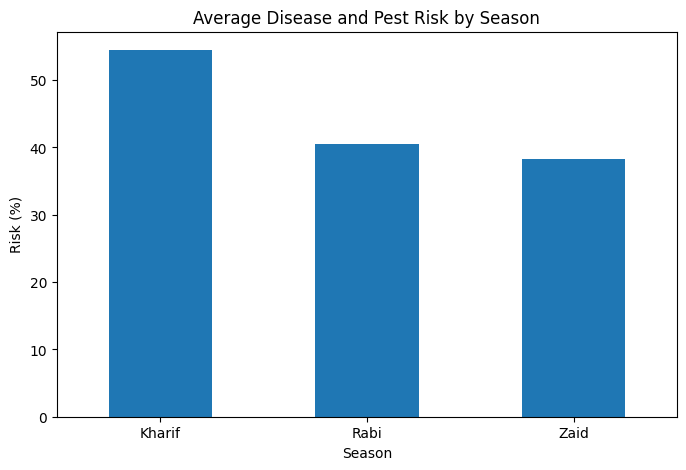

In [22]:
risk_summary = df.groupby("Season")["Disease_Pest_Risk_pct"].mean().round(2).sort_values(ascending=False)

print(risk_summary)

risk_summary.plot(kind="bar", figsize=(8,5))
plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.show()

Season
Kharif    5.89
Rabi      5.19
Zaid      4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64


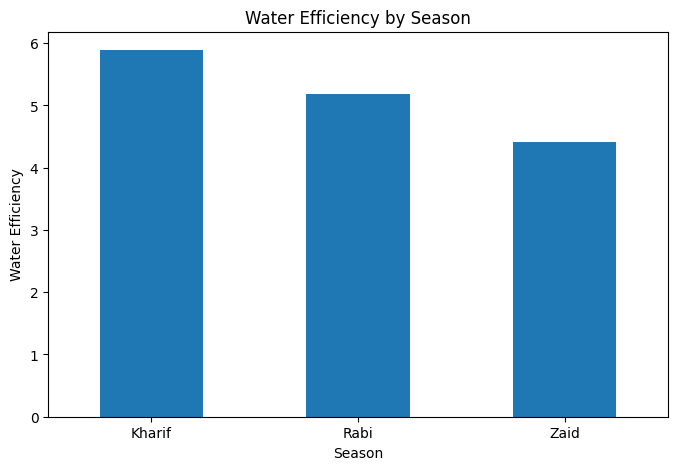

In [23]:
water_summary = df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean().round(2).sort_values(ascending=False)

print(water_summary)

water_summary.plot(kind="bar", figsize=(8,5))
plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")
plt.xticks(rotation=0)
plt.show()